In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate,
)
from tensorflow.keras.models import Model
from sklearn.calibration import LabelEncoder

In [4]:
df = pd.read_parquet("../datasets/full_train_dataset_with_embeddings.parquet")

In [5]:
df = df.dropna(how="any")

In [6]:
le = LabelEncoder()
df["Zipcode_endcoded"] = le.fit_transform(df["Zip-code"])
df = df.drop(columns=["Zip-code"])

In [7]:
df["original_langage_encoded"] = le.fit_transform(df["original_language"])
df = df.drop(columns=["original_language"])

In [8]:
df["occupation_encoded"] = le.fit_transform(df["Occupation"])
df = df.drop(columns=["Occupation"])

In [9]:
df = pd.get_dummies(
    df,
    columns=["Gender"],
    dtype=np.float32,
)

In [10]:
# feature columns
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
    "adult",
]
numeric_cols = ["popularity", "vote_average", "vote_count", "original_langage_encoded"]
user_cols = [
    "UserID",
    "Age",
    "occupation_encoded",
    "Zipcode_endcoded",
    "Gender_M",
    "Gender_F",
]

In [11]:
user_vecs = df[user_cols].to_numpy(dtype=np.float32)
item_vecs = df[genre_cols + numeric_cols].to_numpy(dtype=np.float32)
overview_embdeddings_vecs = np.stack(df["embedding"].values).astype(np.float32)
ratings = df["Rating"].to_numpy(dtype=np.float32)

In [12]:
u_train, u_test, e_train, e_test, i_train, i_test, y_train, y_test = train_test_split(
    user_vecs,
    overview_embdeddings_vecs,
    item_vecs,
    ratings,
    test_size=0.2,
    random_state=42,
)

In [17]:
from tensorflow.keras.utils import to_categorical

In [18]:
y_train_ohe = to_categorical(df["Rating"] - 1, num_classes=5)
y_test_ohe = to_categorical(df["Rating"] - 1, num_classes=5)

In [59]:
n_users = df.UserID.max() + 1  # replace with: df.UserID.max()+1
user_dim = u_train.shape[1]

overview_dim = overview_embdeddings_vecs.shape[1]  # embedding dimension
n_genres = len(genre_cols)
n_numeric = len(numeric_cols)
movie_dim = n_genres + n_numeric

# ——— Inputs ———
inp_user = Input(shape=(user_dim,), name="user_id")
inp_movie = Input(shape=(movie_dim,), name="movie_feat")
inp_overview = Input(shape=(overview_dim,), name="overview_emb_feat")
# ——— User tower ———
u = Embedding(input_dim=n_users, output_dim=32, name="user_emb")(inp_user)
u = Flatten()(u)

# — immediate concat —
x = Concatenate()([u, inp_movie, inp_overview])
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

out = Dense(5, activation="softmax", name="rating")(x)
# linear activation for regression

In [60]:
model = Model([inp_user, inp_movie, inp_overview], out)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_id             │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 6, 32)     │    193,312 │ user_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 192)       │          0 │ user_emb[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_feat          │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ overview_emb_feat   │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 599)       │          0 │ flatten_9[0][0],  │
│ (Concatenate)       │                   │            │ movie_feat[0][0], │
│                     │                   │            │ overview_emb_fea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_81 (Dense)    │ (None, 512)       │    307,200 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_81[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_81          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_82 (Dense)    │ (None, 256)       │    131,328 │ dropout_81[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_82[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_82          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_83 (Dense)    │ (None, 64)        │     16,448 │ dropout_82[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_83[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_83          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_84 (Dense)    │ (None, 32)        │      2,080 │ dropout_83[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_84[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_84          │ (None, 32)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                 

 Total params: 653,989 (2.49 MB)

 Trainable params: 652,261 (2.49 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [61]:
from sklearn.utils.class_weight import compute_class_weight

y_labels = np.argmax(y_train_ohe, axis=1)

classes = np.unique(y_labels)
cw = compute_class_weight("balanced", classes=classes, y=y_labels)
class_weights = dict(zip(classes, cw))

In [63]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor="val_loss", mode="min", patience=3, restore_best_weights=True
)

In [64]:
from sklearn.utils import class_weight

history = model.fit(
    [u_train, i_train, e_train],
    y_labels,
    class_weight=class_weights,
    batch_size=256,
    epochs=15,
    validation_split=0.2,
    callbacks=[es],
)

Epoch 1/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.1853 - loss: 1.6784 - val_accuracy: 0.1011 - val_loss: 1.6185
Epoch 2/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.1062 - loss: 1.6210 - val_accuracy: 0.1433 - val_loss: 1.6149
Epoch 3/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - accuracy: 0.1225 - loss: 1.6186 - val_accuracy: 0.1208 - val_loss: 1.6141
Epoch 4/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.1222 - loss: 1.6170 - val_accuracy: 0.0912 - val_loss: 1.6146
Epoch 5/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.1053 - loss: 1.6191 - val_accuracy: 0.1095 - val_loss: 1.6163
Epoch 6/15
2412/2412 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.0965 - loss: 1.6211 - val_accuracy: 0.0849 - val_loss: 1.6152


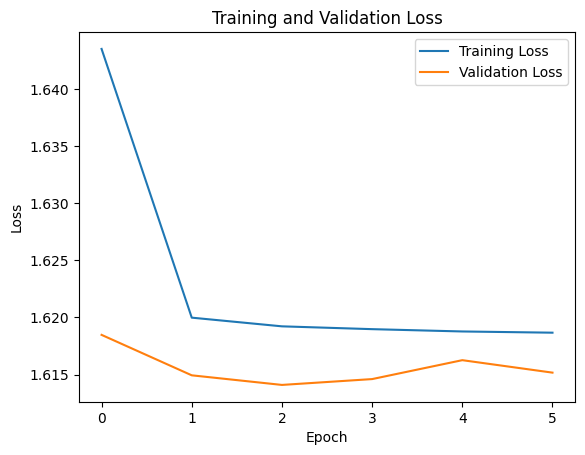

In [65]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [66]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    mean_absolute_error,
    mean_squared_error,
    brier_score_loss,
)

probs = model.predict([u_test, i_test, e_test])
y_pred = np.argmax(probs, axis=1)

print("Acc:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("QWK:", cohen_kappa_score(y_test, y_pred, weights="quadratic"))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print(
    "Brier:",
    brier_score_loss(
        (y_test == 2).astype(int), probs[:, 2]  # example: compute Brier for class “2”
    ),
)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

6030/6030 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Acc: 0.08695043768042332
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       0.07      0.39      0.12     10729
         2.0       0.06      0.01      0.02     20779
         3.0       0.17      0.04      0.07     50372
         4.0       0.33      0.15      0.21     67681
         5.0       0.00      0.00      0.00     43388

    accuracy                           0.09    192949
   macro avg       0.11      0.10      0.07    192949
weighted avg       0.17      0.09      0.10    192949

QWK: 0.0012966138625417623
MAE: 2.6326024532318115


c:\Users\vodil\OneDrive\Desktop\project learning\movie-recommendation-system\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vodil\OneDrive\Desktop\project learning\movie-recommendation-system\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vodil\OneDrive\Desktop\project learning\movie-recommendation-system\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samp

TypeError: got an unexpected keyword argument 'squared'